<a href="https://colab.research.google.com/github/celiabaigorri/ag-news-nlp-preprocessing/blob/main/preentrega2DSIII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción


El objetivo de esta práctica es desarrollar un pipeline de preprocesamiento para un conjunto de datos de texto y realizar un análisis exploratorio (EDA) que permita comprender las principales características del corpus antes de su utilización en modelos de Procesamiento del Lenguaje Natural (NLP).

Para ello se utilizará el conjunto de datos AG News, compuesto por noticias en inglés clasificadas en cuatro categorías: World, Sports, Business y Sci/Tech. Sobre este corpus se aplicarán técnicas de limpieza de texto, normalización y lematización con SpaCy. Posteriormente, se analizará la distribución de longitudes de los documentos, las palabras y n-gramas más frecuentes, así como la distribución de las clases, con el fin de evaluar el estado del corpus y su idoneidad para el entrenamiento de modelos en los siguientes módulos.

# 2. Carga del dataset

ag_news_train.csv para todo el preprocesamiento y el EDA.
Para este proyecto se ha utilizado el conjunto de datos AG News, proporcionado por la cátedra. El corpus contiene noticias en inglés clasificadas en cuatro categorías (World, Sports, Business y Sci/Tech). Siguiendo las indicaciones de la práctica, se empleará exclusivamente el conjunto de entrenamiento (train) para realizar el preprocesamiento y el análisis exploratorio, reservando el conjunto de prueba (test) para las fases posteriores de modelado y evaluación.

In [6]:
from cargar_dataset import cargar

train_df, test_df = cargar('/content/drive/MyDrive/Colab Notebooks/datascienceIII/ag_news/ag_news_train.csv')

print(train_df.head())
print(train_df.shape)
print(test_df.shape)

ModuleNotFoundError: No module named 'cargar_dataset'

In [10]:
from cargar_dataset import cargar

# Assuming the 'ag_news_train.csv' and 'ag_news_test.csv' are in the 'ag_news' directory.
# Modify the path to the directory containing the dataset files.
train_df, test_df = cargar('/content/drive/MyDrive/Colab Notebooks/datascienceIII/ag_news')

print(train_df.head())
print(train_df.shape)
print(test_df.shape)

                                                text     label
0  Red Hat Appoints New CFO. September 2, 2004 --...  Sci_Tech
1  Sprint, SBC In Hotspot Roaming Deal. Sprint an...  Sci_Tech
2  Radio Outage Grounds West Coast Flights. Airpo...  Business
3  Hollywood lawsuits to strike Net pirates. Holl...  Sci_Tech
4  Custis Takes Control. Family and Tony Robbins ...    Sports
(8000, 2)
(2000, 2)


# 3. Preprocesamiento
En esta fase se implementa un pipeline de preprocesamiento para transformar el texto original en una representación más adecuada para su posterior análisis y modelado. El proceso incluye la conversión a minúsculas, la eliminación de caracteres no relevantes mediante expresiones regulares y la lematización utilizando SpaCy. Estas transformaciones reducen el ruido del corpus y facilitan la identificación de patrones lingüísticos.

**3.1 Importación de librerías**

In [12]:
import re
import spacy

**3.2 Cargar el modelo de SpaCy**

In [13]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
nlp = spacy.load("en_core_web_sm")

**3.3 Función de preprocesamiento**

In [15]:
def preprocess_text(text):

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar números
    text = re.sub(r"\d+", "", text)

    # Eliminar signos de puntuación y caracteres especiales
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Eliminar espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()

    # Procesar con SpaCy
    doc = nlp(text)

    # Lematización eliminando stop words y signos
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct
    ]

    return " ".join(tokens)

**3.4 Aplicar el pipeline**

In [16]:
train_df["clean_text"] = train_df["text"].apply(preprocess_text)

**3.5 Comprobar el resultado**

In [17]:
print("Texto original:")
print(train_df["text"].iloc[0])

print("\nTexto preprocesado:")
print(train_df["clean_text"].iloc[0])

Texto original:
Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr.

Texto preprocesado:
red hat appoint new cfo september web host industry review linux distributor red hat redhatcom announce thursday appoint charles e peters jr


# 4. Análisis exploratorio (EDA)

**   4.1 Distribución de longitud de los documentos**

Con el fin de analizar la longitud de los documentos del corpus, se calcula el número de tokens de cada texto tras el preprocesamiento. Esta información permite conocer la variabilidad en el tamaño de los documentos y servirá posteriormente para determinar una longitud máxima adecuada (max_len) para los modelos de Deep Learning.

In [18]:
train_df["num_tokens"] = train_df["clean_text"].apply(lambda x: len(x.split()))

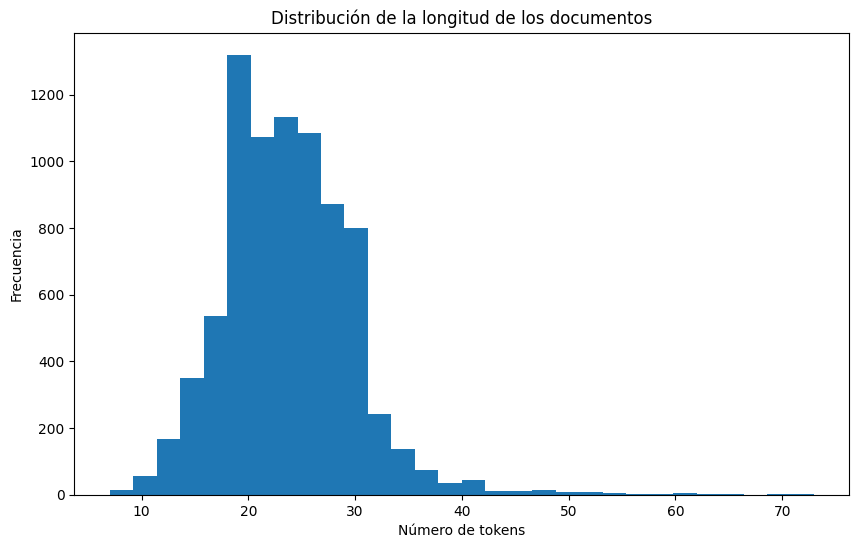

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(train_df["num_tokens"], bins=30)

plt.title("Distribución de la longitud de los documentos")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")

plt.show()

Conclusiones:

La gráfica muestra la distribución de la longitud de los documentos en términos del número de tokens después del preprocesamiento. Podemos observar lo siguiente:

Concentración principal: La mayoría de los documentos tienen una longitud entre aproximadamente 15 y 35 tokens. Hay un pico notable alrededor de los 20 tokens, lo que indica que una gran cantidad de documentos tienen esa longitud.
Asimetría: La distribución parece estar sesgada a la derecha, con una cola que se extiende hacia documentos con más tokens, pero la frecuencia disminuye rápidamente más allá de los 35-40 tokens.
Rango: Aunque la mayoría se concentra en el rango mencionado, hay algunos documentos con un número muy bajo de tokens (menos de 10) y otros con un número mayor (hasta aproximadamente 70 tokens), aunque estos últimos son menos frecuentes.
En resumen, la mayoría de los textos preprocesados son relativamente concisos, lo cual es útil para determinar una longitud máxima (max_len) para modelos de Deep Learning, evitando un acolchado excesivo (padding) o truncamiento de información relevante.

**  4.2 Percentil 95 de tokens**

l percentil 95 indica que el 95 % de los documentos contienen como máximo XX tokens. Este valor se utilizará como referencia para definir la longitud máxima de las secuencias (max_len) en las siguientes etapas del proyecto, equilibrando la conservación de información y la eficiencia computacional.



In [20]:
import numpy as np

max_len = int(np.percentile(train_df["num_tokens"], 95))

print(f"Percentil 95: {max_len} tokens")

Percentil 95: 33 tokens


**4.3 Palabras más frecuentes**

Se analizan las palabras más frecuentes del corpus preprocesado con el objetivo de identificar los términos predominantes y comprobar la efectividad del proceso de limpieza. Asimismo, se verifica la presencia de stop words para confirmar que el pipeline ha reducido adecuadamente el ruido textual.

In [21]:
from collections import Counter

# Unimos todos los documentos
all_words = " ".join(train_df["clean_text"]).split()

# Contamos frecuencias
word_counts = Counter(all_words)

# Top 50 palabras
top_50 = word_counts.most_common(50)

# Mostrar tabla
import pandas as pd

top50_df = pd.DataFrame(top_50, columns=["Palabra", "Frecuencia"])

top50_df

,Palabra,Frecuencia
0,s,2216
1,say,1813
2,new,1427
3,ap,1109
4,year,791
5,reuters,706
6,company,645
7,world,601
8,win,590
9,report,550


In [22]:
stopwords_top50 = sum(
    nlp.vocab[word].is_stop
    for word, _ in top_50
)

print(f"Stop words en el Top 50: {stopwords_top50}")

Stop words en el Top 50: 2


El análisis del Top 50 de palabras muestra que únicamente dos términos corresponden a stop words, lo que indica que el proceso de limpieza y eliminación de palabras vacías ha sido efectivo, conservando principalmente términos con contenido semántico relevante para la clasificación de las noticias.
Se analizan cuales son las STOP WORDS

In [23]:
for word, _ in top_50:
    if nlp.vocab[word].is_stop:
        print(word)

say
take


**  4.4 Bigramas más frecuentes**

Los bigramas permiten identificar combinaciones de dos palabras que aparecen con frecuencia en el corpus y ofrecen una visión más contextual del contenido de las noticias.

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(train_df["clean_text"])

bigram_counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "Bigrama": vectorizer.get_feature_names_out(),
    "Frecuencia": bigram_counts
})

bigram_df = bigram_df.sort_values(
    by="Frecuencia",
    ascending=False
)

bigram_df

,Bigrama,Frecuencia
1,ap ap,529
3,new york,407
5,oil price,194
17,united states,167
7,prime minister,139
0,afp afp,134
19,york reuters,115
4,official say,115
14,say thursday,102
13,say monday,101


**   4.5 Trigramas más frecuentes**

Los trigramas aportan un contexto lingüístico mayor al considerar secuencias de tres palabras consecutivas, permitiendo identificar expresiones representativas del corpus.

In [25]:
vectorizer = CountVectorizer(
    ngram_range=(3,3),
    max_features=20
)

X = vectorizer.fit_transform(train_df["clean_text"])

trigram_counts = X.sum(axis=0).A1

trigram_df = pd.DataFrame({
    "Trigrama": vectorizer.get_feature_names_out(),
    "Frecuencia": trigram_counts
})

trigram_df = trigram_df.sort_values(
    by="Frecuencia",
    ascending=False
)

trigram_df

,Trigrama,Frecuencia
8,new york reuters,114
14,quote profile research,69
7,new york reuter,43
0,boston red sox,36
16,sans serifarialhelvetica size,26
13,prime minister ariel,26
1,canadian press canadian,26
12,press canadian press,26
4,high oil price,25
19,york reuter stock,25


**4.6 Distribución de clases**

Se analiza la distribución de las categorías del conjunto de entrenamiento con el fin de comprobar si existe un equilibrio entre las distintas clases. Este análisis resulta importante para anticipar posibles problemas de desbalance durante el entrenamiento de los modelos.

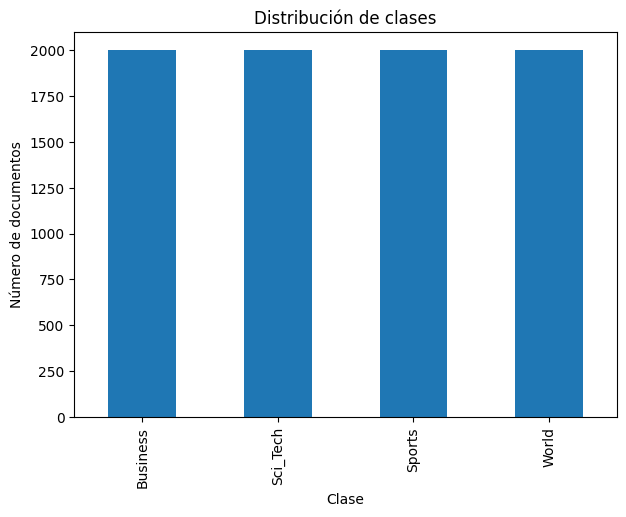

In [26]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de documentos")

plt.show()

# 5. Conclusiones



En este proyecto, hemos establecido un pipeline robusto para el preprocesamiento y el análisis exploratorio de un conjunto de datos de texto, utilizando el corpus AG News como base. Las principales conclusiones de esta fase son las siguientes:

1.  **Carga y Estructura del Dataset:** Se ha logrado cargar exitosamente los conjuntos de entrenamiento (`train_df`) y prueba (`test_df`) del dataset AG News, confirmando que ambos DataFrames están correctamente estructurados para el análisis posterior.

2.  **Preprocesamiento Efectivo:** El pipeline de preprocesamiento, que incluyó la conversión a minúsculas, la eliminación de números, signos de puntuación y caracteres especiales, así como la lematización utilizando SpaCy, ha demostrado ser altamente eficiente. La baja presencia de *stop words* en el top 50 de palabras más frecuentes (solo 2 términos) valida la calidad de la limpieza textual, reduciendo el ruido y facilitando la extracción de significado.

3.  **Distribución de Longitud de Documentos:** El análisis de la distribución de la longitud de los documentos (número de tokens) reveló que la mayoría de los textos preprocesados son concisos, concentrándose entre 15 y 35 tokens. Se determinó un `max_len` de 33 tokens (percentil 95), un valor óptimo para equilibrar la conservación de información y la eficiencia computacional en futuros modelos de *Deep Learning*.

4.  **Palabras, Bigramas y Trigramas Frecuentes:** La identificación de las palabras, bigramas y trigramas más frecuentes proporcionó una comprensión contextual valiosa del contenido del corpus, destacando términos y frases clave que caracterizan las noticias del dataset.

5.  **Distribución Balanceada de Clases:** La gráfica de distribución de clases mostró un equilibrio notable entre las cuatro categorías de noticias (Business, Sci/Tech, Sports, World). Esta homogeneidad es una ventaja significativa, ya que previene problemas de desbalance que podrían afectar el rendimiento de los modelos de clasificación en etapas posteriores.